        trades  win_rate     avg_pnl     total_pnl
regime                                            
bull        65  0.581633  525.101619  34131.605212
side        55  0.350877   80.495607   4427.258365
bear        46  0.206612 -196.063386  -9018.915759


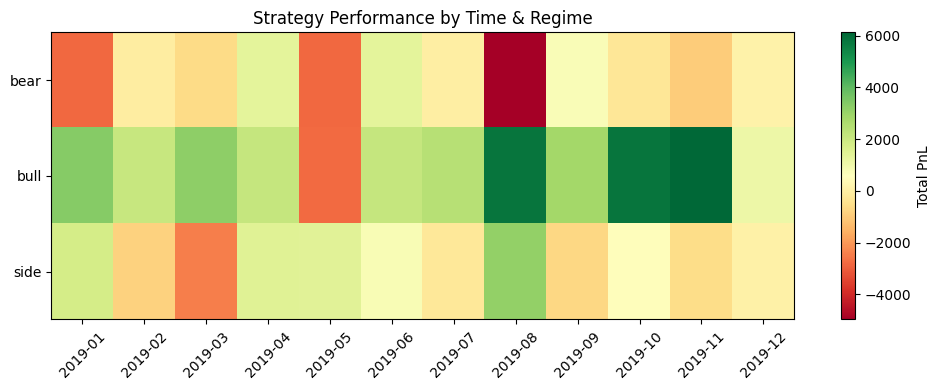

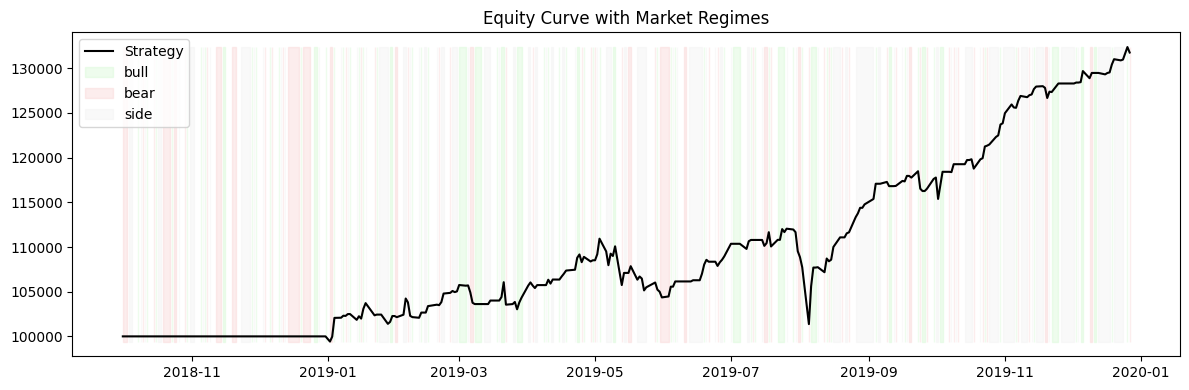

In [15]:
import pandas as pd
import numpy as np

def classify_market_regime(
    close: pd.Series,
    lookback: int = 96,   # ~1 trading day for 5m bars
    trend_th: float = 0.003
):
    """
    Returns: Series with values {'bull', 'bear', 'side'}
    """
    ret = close.pct_change(lookback)

    regime = pd.Series(index=close.index, dtype=object)
    regime[ret >  trend_th] = "bull"
    regime[ret < -trend_th] = "bear"
    regime[(ret >= -trend_th) & (ret <= trend_th)] = "side"

    return regime

# trades from your system
trades = pd.read_csv("trades_QQQ_K_5M.csv")
trades["timestamp"] = pd.to_datetime(trades["signal_ts"])

# price data (same CSV used in backtest)
price = pd.read_csv("../DataAPI/data/QQQ_5M.csv")
price["timestamp"] = pd.to_datetime(price["timestamp"])
price = price.set_index("timestamp").sort_index()

# classify regime
price["regime"] = classify_market_regime(price["Close"])

# attach regime to each trade (by execution time)
trades["regime"] = trades["timestamp"].map(
    price["regime"]
)
summary = (
    trades
    .groupby("regime")
    .agg(
        trades=("pnl", "count"),
        win_rate=("pnl", lambda x: (x > 0).mean()),
        avg_pnl=("pnl", "mean"),
        total_pnl=("pnl", "sum"),
    )
    .sort_values("total_pnl", ascending=False)
)

print(summary)
trades["month"] = trades["timestamp"].dt.to_period("M")

heat = (
    trades
    .groupby(["month", "regime"])["pnl"]
    .sum()
    .unstack(fill_value=0)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.imshow(heat.T, aspect="auto", cmap="RdYlGn")
plt.yticks(range(len(heat.columns)), heat.columns)
plt.xticks(range(len(heat.index)), heat.index.astype(str), rotation=45)
plt.colorbar(label="Total PnL")
plt.title("Strategy Performance by Time & Regime")
plt.tight_layout()
plt.show()
# daily equity curve from your output
daily = pd.read_csv("daily_equity_QQQ_K_5M.csv")
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.set_index("date")

# align daily regime
daily["regime"] = daily.index.map(
    price.resample("1D").last()["regime"]
)

plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily["equity"], label="Strategy", color="black")

for regime, color in {
    "bull": "#c8f7c5",
    "bear": "#f7c5c5",
    "side": "#eeeeee",
}.items():
    mask = daily["regime"] == regime
    plt.fill_between(
        daily.index,
        daily["equity"].min(),
        daily["equity"].max(),
        where=mask,
        color=color,
        alpha=0.3,
        label=regime
    )

plt.title("Equity Curve with Market Regimes")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()
